In [123]:
#Inputting the csv files containing the yield data and experimental data 
import pandas as pd

df_yield_data = pd.read_csv(r"C:\Users\imoge\Y1_Yield_Data.csv")
df_exp = pd.read_csv(r"C:\Users\imoge\Y1 Reactions.csv")

In [124]:
#This cell contains a set of functions to calculate the sustainability metrics featured in the outputs
def average_product_mass(function_theoretical_yield, average_yield):
    function_product_mass = function_theoretical_yield*(average_yield/100)
    return function_product_mass
#average product mass uses the percentage yield from an experiment, and the theoretical yield of the reaction to calculate the mass of the product

def m_e(function_product_mass, function_reactant_mass):
    function_mass_efficiency = (function_product_mass/function_reactant_mass)*100
    return function_mass_efficiency
#mass efficiency represents the percentage of mass of reactants present in the product

def emy(function_product_mass, function_mass_of_hazardous_reagents):
    function_emy = (function_product_mass/function_mass_of_hazardous_reagents)*100
    return function_emy
#emy is the effective mass yield, which shows the ratio of product mass compared to the mass of hazardous reagents in the reaction

def MI(function_total_mass_in_process, function_product_mass):
    function_mass_intensity = function_total_mass_in_process/function_product_mass
    return function_mass_intensity
#mass intensity represents the amount of mass entering the reaction per 1g of product

def sum_of_waste(function_total_mass_in_process, function_product_mass):
    function_sum_of_waste = function_total_mass_in_process-function_product_mass
    return function_sum_of_waste
#sum of waste refers to all waste generated by the reaction, including solvents, work ups and purifications

def EF(function_waste, function_product_mass):
    function_e_factor = function_waste/function_product_mass
    return function_e_factor
#e-factor refers to the amounf of waste produced by the reaction per 1g of product

In [125]:
reaction_codes= df_exp["Reaction"].unique()

In [126]:
#this function calculates the sustainability metrics from the csv files inputted in the first cell
def metric_calculations(function_df_exp, function_df_yield_data):
        avg_yield = []
        theo_yield =[]
        avg_product = [] 
        mass_eff = []
        eff_mass_yield = []
        mass_inten = [] 
        wasted = []
        e_fact = [] 
    
        for i in reaction_codes: 
        
            filtered_df_exp = df_exp[df_exp["Reaction"]==i]
            theoretical_yield = filtered_df_exp["Theoretical yield"].values[0] 
        
            filtered_df_yield_data = df_yield_data[df_yield_data["Experiment Code"]==i]
            average_yield_df = filtered_df_yield_data["Percentage Yield (%)"].mean()
            avg_yield.append(average_yield_df)
            theo_yield.append(theoretical_yield)
        
            average_product = average_product_mass(theoretical_yield, average_yield_df)  
            avg_product.append(average_product)

            reactant_mass = filtered_df_exp["Mass of reactants"].values[0]
            mass_efficiency = m_e(average_product, reactant_mass)
            mass_eff.append(mass_efficiency)

            mass_of_hazardous_reagents = filtered_df_exp["Mass of hazardous reagents"].values[0]
            EMY = emy(average_product, mass_of_hazardous_reagents)
            eff_mass_yield.append(EMY)
        
            total_mass_in_process = filtered_df_exp["Total mass in process"].values[0]
            mass_intensity = MI(total_mass_in_process, average_product)
            mass_inten.append(mass_intensity)
    
            waste = sum_of_waste(total_mass_in_process, average_product)
            wasted.append(waste)

            e_factor = EF(waste, average_product)
            e_fact.append(e_factor)
            
        return avg_yield, theo_yield, avg_product, mass_eff, eff_mass_yield, mass_inten, wasted, e_fact

In [127]:
#this function makes a new csv file containing the sustainability metrics calculated by this notebook
def sustainability_metric_calc(yield_data, experiment_data): 
    reaction_codes= df_exp["Reaction"].unique()        
    avg_y, theo_y, avg_prd, m_eff, eff_m_y, mass_int, wast, e_f = metric_calculations(df_exp, df_yield_data)
    import pandas as pd    
    df_metrics = pd.DataFrame({
        "Reaction": reaction_codes,
        "Average Yield (%)": avg_y,
        "Theoretical Yield (%)": theo_y,
        "Average Product Mass": avg_prd, 
        "Average Mass Efficiency": m_eff,
        "Average Effective Mass Yield": eff_m_y,
        "Average Mass Intensity": mass_int, 
        "Average Sum of Waste": wast,
        "Average E-Factor": e_f})

    df_metrics.to_csv("metrics.csv", index=False)
    return df_metrics

In [128]:
#this function makes a bar chart showing mass intensity for the reactions
def mass_int_plot(metric_data):
    import plotly.express as px
    fig_mi = px.bar (metric_data, x = "Reaction", y = "Average Mass Intensity", title = "Average Mass intensity",)
    fig_mi.update_yaxes(range=[0,700])
    fig_mi.update_yaxes(nticks=14)
    fig_mi.show()
    return fig_mi


In [129]:
#this function makes a bar chart showing the mass of waste produce per student for each reaction
def mass_of_waste_plot(metric_data): 
    import plotly.express as px
    df_metrics_copy = metric_data.copy()
    df_metrics_copy["Average Sum of Waste"] = metric_data["Average Sum of Waste"] / 1000
    fig_mw = px.bar(df_metrics_copy,
        x="Reaction",
        y="Average Sum of Waste",
        labels={
            "Reaction": "Reaction Code",
            "Average Sum of Waste": "Mass (g)"},
    title="Mass of Waste Produced by an Average Student")
    fig_mw.update_yaxes(nticks=10)
    fig_mw.update_yaxes(range=[0,350])
    fig_mw.show()
    return fig_mw


In [130]:
#this function makes a box plot showing the distribution of percentage yields for each reaction
def percentage_plot (yield_data):
    import plotly.express as px
    fig_pp = px.box(yield_data, x= "Experiment Code",y= "Percentage Yield (%)", )
    fig_pp.show()
    return fig_pp


In [131]:
#this function produces box plots for each of the reactions, showing the distribution of percentage yields and which yields result in a good, moderate or poor e-factor
def e_factor_box (data_exp, yield_data): 
    reaction_codes= data_exp["Reaction"].unique()
    for i in reaction_codes:
        filtered_df_exp = data_exp[data_exp["Reaction"]==i]
        filtered_df_yield = yield_data[yield_data["Experiment Code"]==i]
        theoretical_yield = filtered_df_exp["Theoretical yield"].values[0]
        total_mass_in_process = filtered_df_exp["Total mass in process"].values[0]

        ef_100_mass_prod = total_mass_in_process/101
        ef_lower_boundary = (ef_100_mass_prod/theoretical_yield)*100

        ef_25_mass_prod = total_mass_in_process/26
        ef_upper_boundary = (ef_25_mass_prod/theoretical_yield)*100
        
        import plotly.express as px
        fig_efb = px.box(filtered_df_yield, x="Experiment Code", y ="Percentage Yield (%)", color_discrete_sequence=["black"])
        fig_efb.add_shape(type="rect", x0=-0.28, x1=0.28, y0=ef_lower_boundary, y1=ef_upper_boundary, fillcolor ="#FFFF00", opacity=0.5, layer="below", line_width=0)
        fig_efb.add_shape(type="rect", x0=-0.28, x1=0.28, y0=ef_upper_boundary, y1=100, fillcolor ="#92D050", opacity=0.5, layer ="below", line_width=0)
        fig_efb.add_shape(type="rect", x0=-0.28, x1=0.28, y0=0, y1=ef_lower_boundary, fillcolor ="#FF0000", opacity=0.5, layer ="below", line_width=0)

        fig_efb.update_layout(font=dict(family="Arial", size=14, color="black"))
        fig_efb.update_layout(title="Range of Percentage Yield Values in a<br>Cohort Compared with E-Factor")
        fig_efb.update_yaxes(range=[0, 100])
        import plotly.graph_objects as go
        fig_efb.add_trace(go.Scatter( x=[None], y=[None], mode="markers", marker=dict(size=10, color="#92D050"), line=dict(color="red", dash="dash"), name="E-Factor ≤ 25 ")) # text that appears in the legend
        fig_efb.add_trace(go.Scatter( x=[None], y=[None], mode="markers", marker=dict(size=10, color="#FFFF00"), line=dict(color="red", dash="dash"), name="E-Factor 25 < X ≤ 100"))
        fig_efb.add_trace(go.Scatter( x=[None], y=[None], mode="markers", marker=dict(size=10, color="#FF0000"), line=dict(color="red", dash="dash"), name="E-Factor > 100"))
        fig_efb.show()



In [132]:
#generates a data frame showing a range of percentage yields
percentage_range = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

df_percent_range = pd.DataFrame({"Percentage": percentage_range})

In [133]:
#this function calculates the product masses at 10, 20, 30 etc. % 
def range_product_mass(data_percentage, exp_data):
    percentages = data_percentage["Percentage"].unique()
    
    reaction_codes= df_exp["Reaction"].unique()
    
    product_masses = []
    
    for i in reaction_codes:
        filtered_df_yield = exp_data[exp_data["Reaction"]==i]
        theo_yld = filtered_df_yield["Theoretical yield"].values[0]

        for p in percentages:
            product_mass = theo_yld * (p / 100)
            product_masses.append(product_mass)
            
    df_prod_mass_range = pd.DataFrame({"Product mass": product_masses})  
    return product_masses



In [134]:
#forms a data frame of the product masses at 10, 20, 30 etc. % 
df_prod_mass_range = pd.DataFrame({"Product mass": product_masses})

import numpy as np
n_cols = 5
values_pm = df_prod_mass_range["Product mass"].values

df_yield_per_react = pd.DataFrame(values_pm.reshape(-1, n_cols, order="F"), columns=["Y1O-001", "Y1O-002", "Y1O-003", "Y1O-004", "Y1O-005"])

df_yield_per_react.index = df_percent_range["Percentage"]

In [135]:
#this function calculates the sum of waste based on the product masses at 10, 20, 30 etc. %
def sum_waste_range_calculation(exp_data, product_data_per_react):
    reaction_codes = exp_data["Reaction"].unique()

    sum_was = []

    for i in reaction_codes:
        filtered_df_exp = exp_data[exp_data["Reaction"]==i]
        product_mass = product_data_per_react[i].unique()
        total_mass = filtered_df_exp["Total mass in process"].values[0]

        for p in product_mass:
            waste = sum_of_waste(total_mass, p)
            sum_was.append(waste)
            
    df_sum_was = pd.DataFrame({
    "sum of waste": sum_was})            
    return df_sum_was 


In [136]:
#makes a data frame of the sum of waste values to use in the next calculation
values = df_sum_was["sum of waste"].to_numpy()

df_sum_was_10x5 = pd.DataFrame(values.reshape(10, 5, order='F'),columns=["Y1O-001", "Y1O-002", "Y1O-003", "Y1O-004", "Y1O-005"])

In [137]:
#this function calculates e-factor from the sum of waste and product masses at 10, 20, 30 etc. %
def e_factor_range_calculations(waste_data, product_data_per_react):
    reaction_codes = waste_data. columns
    percentage_range = [10,20,30,40,50,60,70,80,90,100]
    
    e_factor_set = []
    for i in reaction_codes:
        waste_values = waste_data[i].values
        product_masses = product_data_per_react[i].values
       
        for w, pm, pct in zip(waste_values, product_masses, percentage_range):
            ef = EF(w, pm)
            e_factor_set.append({
                "Reaction":i,
                "Waste":w,
                "Product Mass": pm,
                "E-Factor": ef,
                "Percentage Yield": pct})
            df_e_factor_set = pd.DataFrame(e_factor_set)
    return df_e_factor_set

In [138]:
#produces a line graph for the e-factor values at 10, 20, 30 etc. % for the reactions
def e_factor_val_graph (e_factor_values):
    import plotly.express as px
    fig_efl = px.line (e_factor_values, x= "Percentage Yield", y= "E-Factor", color="Reaction", markers=True,
                labels={ 
                  "E-Factor" : "E-factor",
                  "Percentage Yield" : "Percentage Yield (%)",
                  "Reaction" : "Reaction Code"},
               title = "Range of E-Factor Values for a Range of Percentage Yields")
    fig_efl.update_yaxes(nticks=20)
    fig_efl.update_yaxes(range=[-100,3500])
    fig_efl.update_xaxes(nticks=20)#
    fig_efl.update_layout(height=600)
    fig_efl.show()
    return fig_efl

In [139]:
#this function plots individual graphs for the e-factor values for masses at 10, 20, 30 etc. % for each reaction
import plotly.express as px

def plot_single_reaction(df, reaction_code):

    # Filter for the chosen reaction
    df_r = df[df["Reaction"] == reaction_code].copy()

    # Classification function
    def classify(v):
        if v < 25:
            return "High"
        elif v < 101:
            return "Moderate"
        else:
            return "Low"

    # Apply classification to the E-Factor column
    df_r["Status"] = df_r["E-Factor"].apply(classify)

    # Plot
    fig = px.line(
        df_r,
        x="Percentage Yield",
        y="E-Factor",
        markers=True,
        title=f"E‑Factor vs Percentage Yield for {reaction_code}",
        labels={
            "Percentage Yield": "Percentage Yield (%)",
            "E-Factor": "E‑Factor"})

    # Colour markers based on status
    fig.update_traces(
        marker=dict(
            size=10,
            color=df_r["Status"].map({
                "High": "#92D050",      # green
                "Moderate": "#FFFF00",  # yellow
                "Low": "#FF0000"        # red
            })),
    line=dict(color="black"))

    fig.update_layout(
        font=dict(family="Arial", size=14, color="black"),
        height=500)
    fig.update_xaxes(nticks=10)
    fig.update_yaxes(nticks=10)

    return fig


In [140]:
#calculates the values for emy for the values at 10, 20, 30 etc. % for the reactions
def emy_range_calculations(product_data_per_react, exp_data):

    reaction_codes = exp_data["Reaction"].unique()
    percentage_range = [10,20,30,40,50,60,70,80,90,100]

    emy_set = []

    for rxn in reaction_codes:
        product_masses = product_data_per_react[rxn].values
        hazard_mass = exp_data.loc[exp_data["Reaction"] == rxn,"Mass of hazardous reagents"].values[0]

        for pm, pct in zip(product_masses, percentage_range):
            EMY = emy(pm, hazard_mass)

            emy_set.append({
                "Reaction": rxn,
                "Mass of Hazardous Reagents": hazard_mass,
                "Product Mass": pm,
                "EMY": EMY,
                "Percentage Yield": pct})

    return pd.DataFrame(emy_set)

In [141]:
#produces a line graph for the emy values at 10, 20, 30 etc. % for the reactions
def emy_val_graph (emy_values):
    import plotly.express as px
    fig = px.line (emy_values, x= "Percentage Yield", y= "EMY", color="Reaction", markers=True,
                labels={ 
                  "EMY" : "EMY",
                  "Percentage Yield" : "Percentage Yield (%)",
                  "Reaction" : "Reaction Code"},
               title = "Range of EMY Values for a Range of Percentage Yields")
    fig.update_yaxes(nticks=20)
    fig.update_yaxes(range=[-5,100])
    fig.update_xaxes(nticks=20)#
    fig.update_layout(height=600)
    fig.show()
    return fig

In [142]:
#calculates the values for mass efficiency for the values at 10, 20 30 etc. % for the reactions
def me_range_calculations(product_data_per_react, exp_data):

    reaction_codes = exp_data["Reaction"].unique()
    percentage_range = [10,20,30,40,50,60,70,80,90,100]

    me_set = []

    for rxn in reaction_codes:
        product_masses = product_data_per_react[rxn].values
        reactant_mass = exp_data.loc[exp_data["Reaction"] == rxn,"Mass of reactants"].values[0]

        for pm, pct in zip(product_masses, percentage_range):
            ME = (pm/reactant_mass)*100
        

            me_set.append({
                "Reaction": rxn,
                "Mass of reactants": reactant_mass,
                "Product Mass": pm,
                "ME": ME,
                "Percentage Yield": pct})

    return pd.DataFrame(me_set)

In [143]:
#produces a line graph for the mass efficiency values at 10, 20, 30 etc. % for the reactions
def me_val_graph (me_values):
    import plotly.express as px
    fig = px.line (me_values, x= "Percentage Yield", y= "ME", color="Reaction", markers=True,
                labels={ 
                  "ME" : "ME",
                  "Percentage Yield" : "Percentage Yield (%)",
                  "Reaction" : "Reaction Code"},
               title = "Range of Mass Efficiency Values for a Range of Percentage Yields")
    fig.update_yaxes(nticks=20)
    fig.update_yaxes(range=[-5,100])
    fig.update_xaxes(nticks=20)#
    fig.update_layout(height=600)
    fig.show()
    return fig

In [144]:
#calculates the values for mass intensity for the values at 10, 20 30 etc. % for the reactions
def mass_i_calculations(exp_data, product_data_per_react):

    reaction_codes = exp_data["Reaction"].unique()
    percentage_range = [10,20,30,40,50,60,70,80,90,100]

    mi_set = []

    for rxn in reaction_codes:
        product_masses = product_data_per_react[rxn].values
        total_mass = exp_data.loc[exp_data["Reaction"] == rxn,"Total mass in process"].values[0]

        for pm, pct in zip(product_masses, percentage_range):
            mass_intensity_val = total_mass/pm
            mi_set.append({
                "Reaction": rxn,
                "Total mass of reactants": total_mass,
                "Product Mass": pm,
                "Mass Intensity": mass_intensity_val,
                "Percentage Yield": pct})

    return pd.DataFrame(mi_set)

In [145]:
#produces a line graph for the mass intensity values at 10, 20, 30 etc. % for the reactions
def mi_val_graph (mi_values):
    import plotly.express as px
    fig = px.line (mi_values, x= "Percentage Yield", y= "Mass Intensity", color="Reaction", markers=True,
                labels={ 
                  "Mass Intensity" : "Mass Intensity",
                  "Percentage Yield" : "Percentage Yield (%)",
                  "Reaction" : "Reaction Code"},
               title = "Range of Mass Intensity Values for a Range of Percentage Yields")
    fig.update_yaxes(nticks=20)
    fig.update_yaxes(range=[-5, 3500])
    fig.update_xaxes(nticks=20)#
    fig.update_layout(height=600)
    return fig

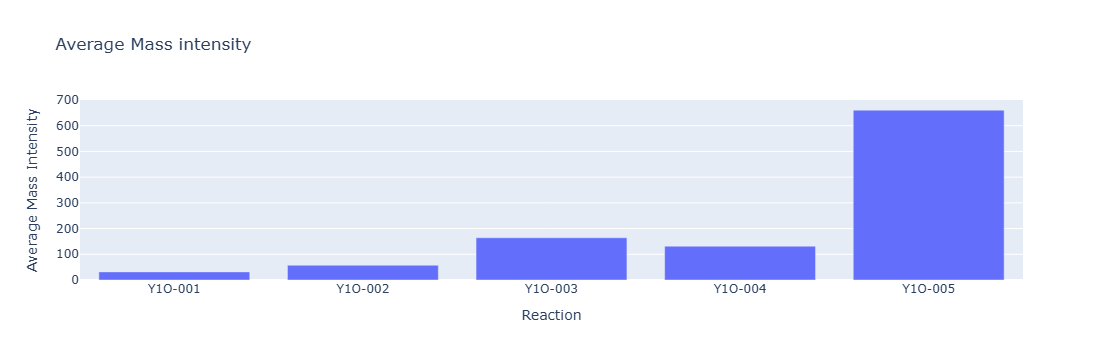

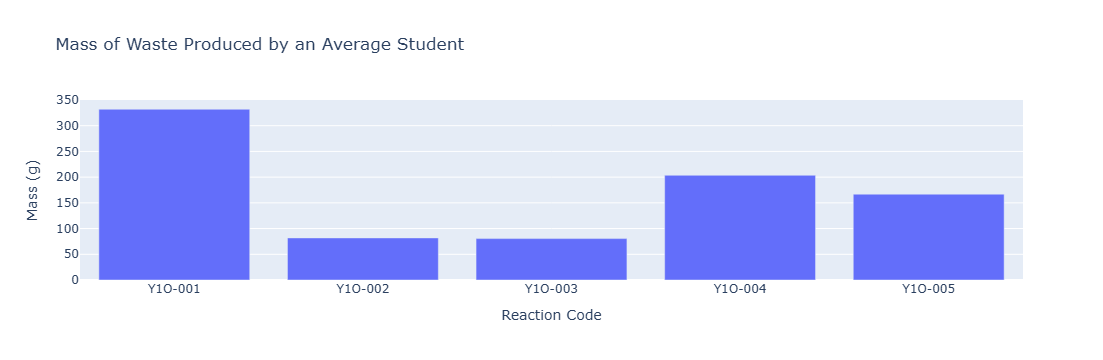

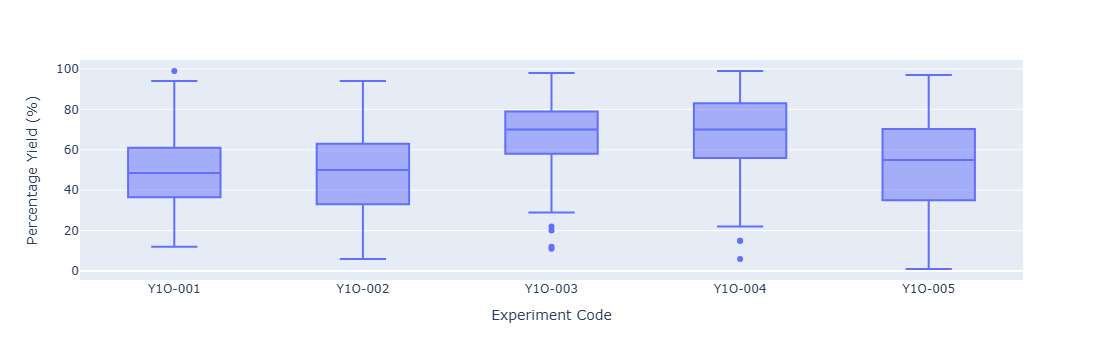

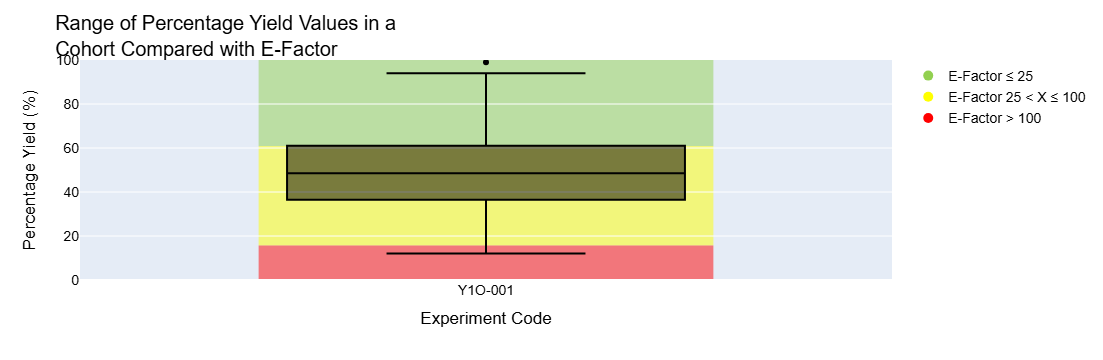

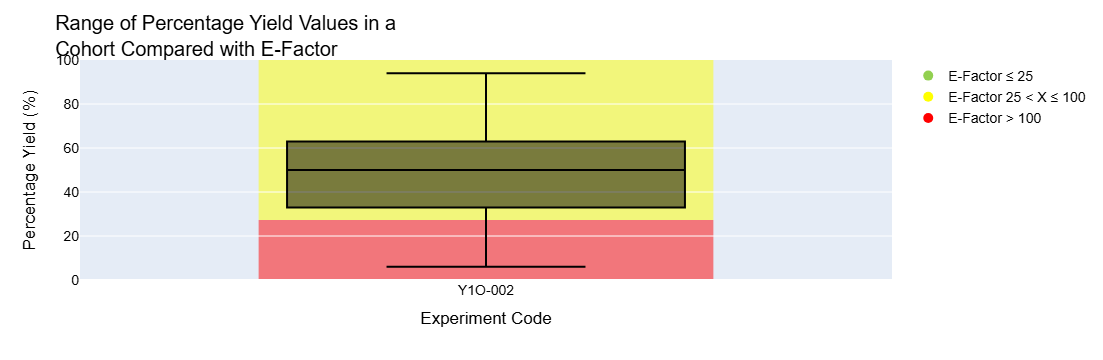

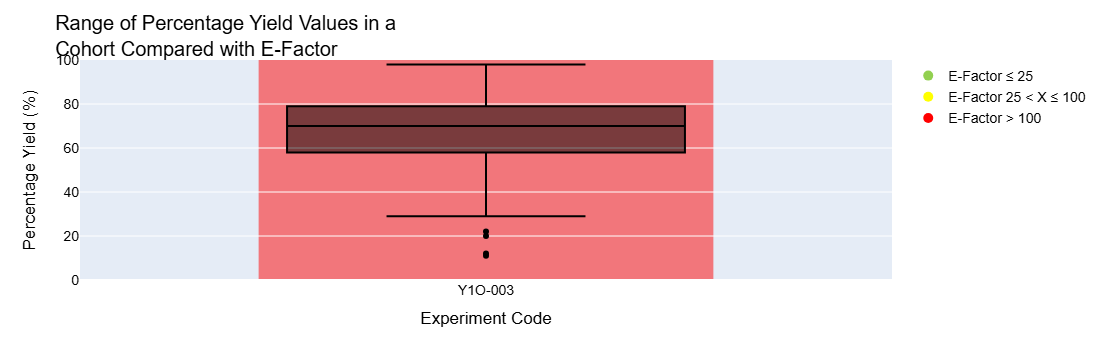

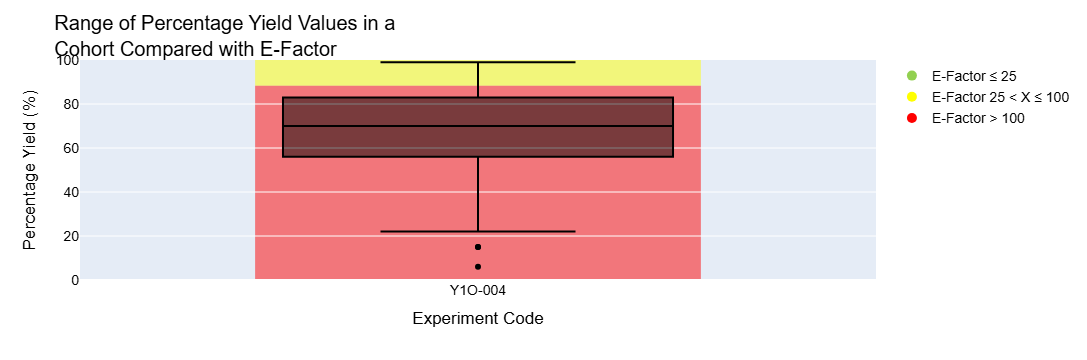

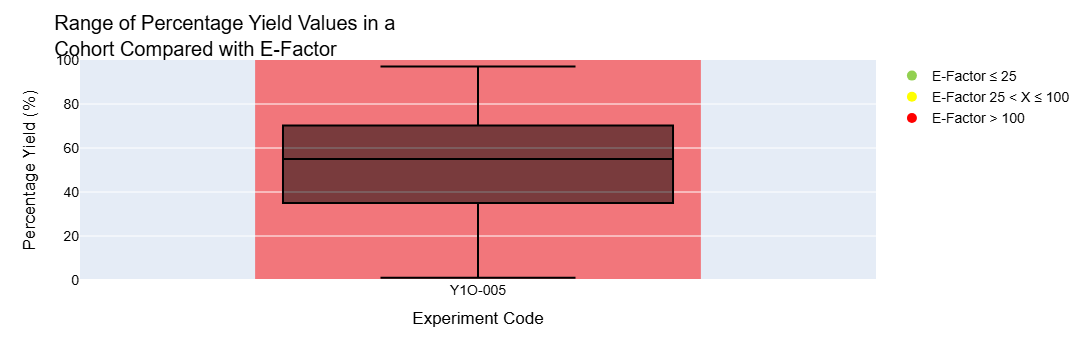

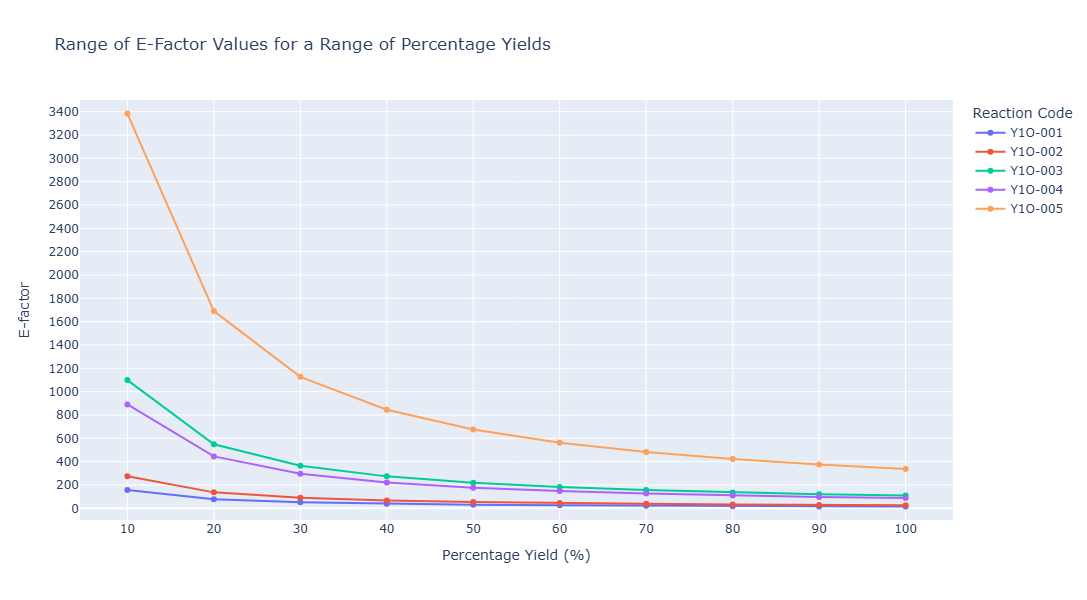

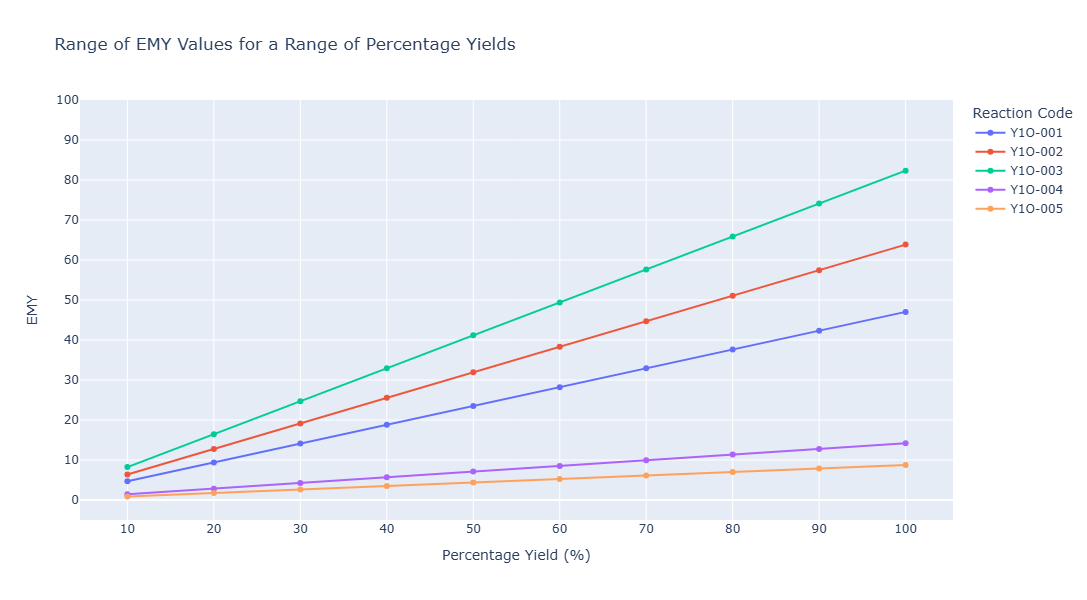

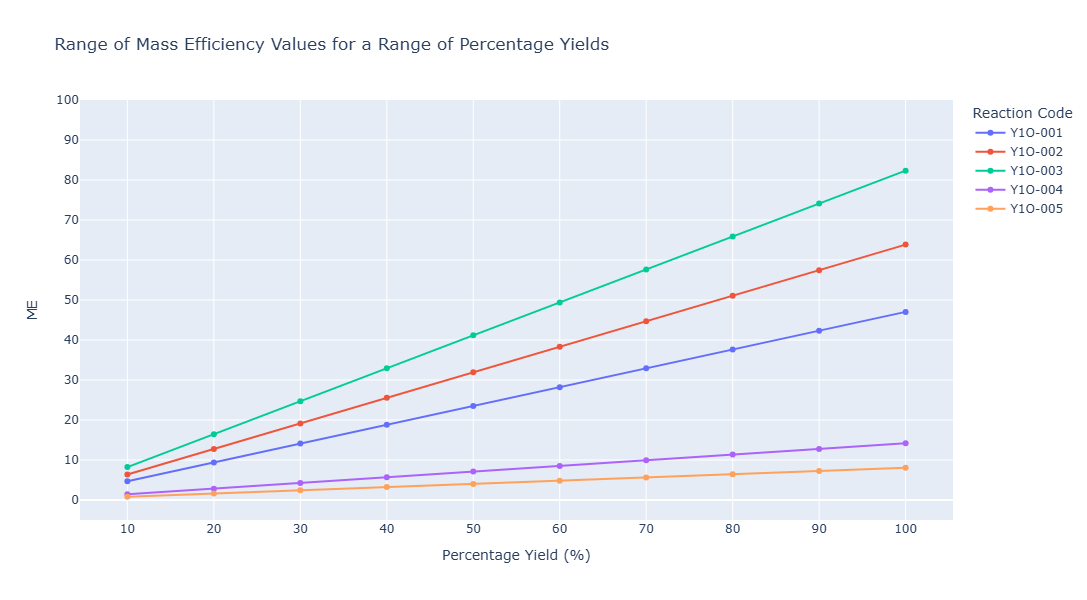

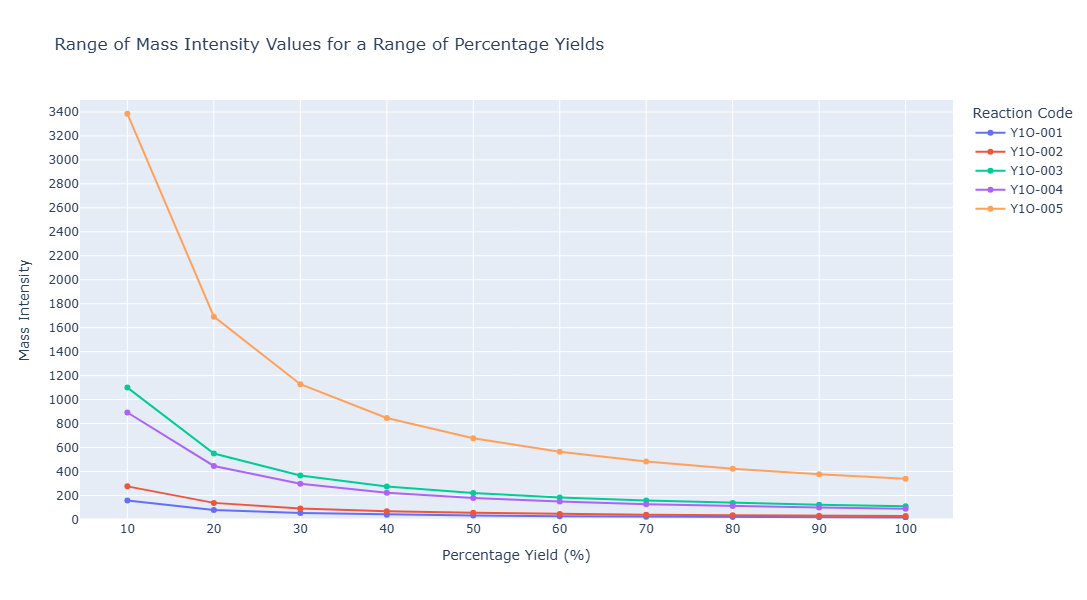

In [146]:
#this calls all of the functions to produce a csv file containing the metric data, and produce the graphs to visualise the data 
sustainability_metric_calc(df_yield_data, df_exp)

mass_intensity_plot = mass_int_plot(df_metrics)

mass_of_waste_student_plot = mass_of_waste_plot(df_metrics)

percentage_yield_plot = percentage_plot(df_yield_data)

e_factor_box(df_exp, df_yield_data) 

product_masses = range_product_mass(df_percent_range, df_exp)

df_sum_was = sum_waste_range_calculation(df_exp, df_yield_per_react)

df_e_factor_values = e_factor_range_calculations(df_sum_was_10x5, df_yield_per_react)

large_e_factor_graph = e_factor_val_graph(df_e_factor_values)

df_emy_values = emy_range_calculations(df_yield_per_react, df_exp)

emy_val_graph(df_emy_values)

df_me_values = me_range_calculations(df_yield_per_react, df_exp)

me_val_graph(df_me_values)

df_mi_values = mass_i_calculations(df_exp, df_yield_per_react)

mi_val_graph(df_mi_values)

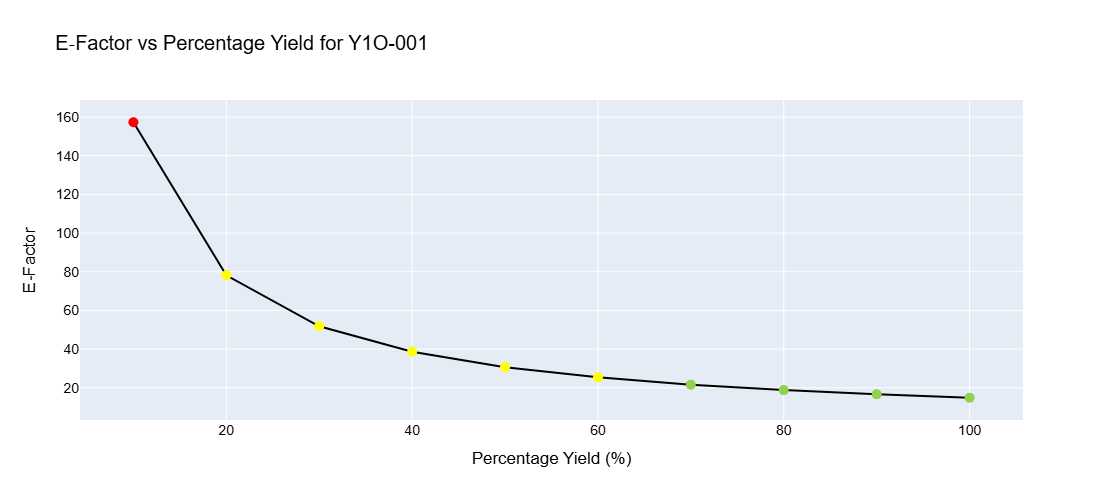

In [147]:
#plots the e-factor line graph for reaction 1
plot_single_reaction(df_e_factor_values, "Y1O-001")

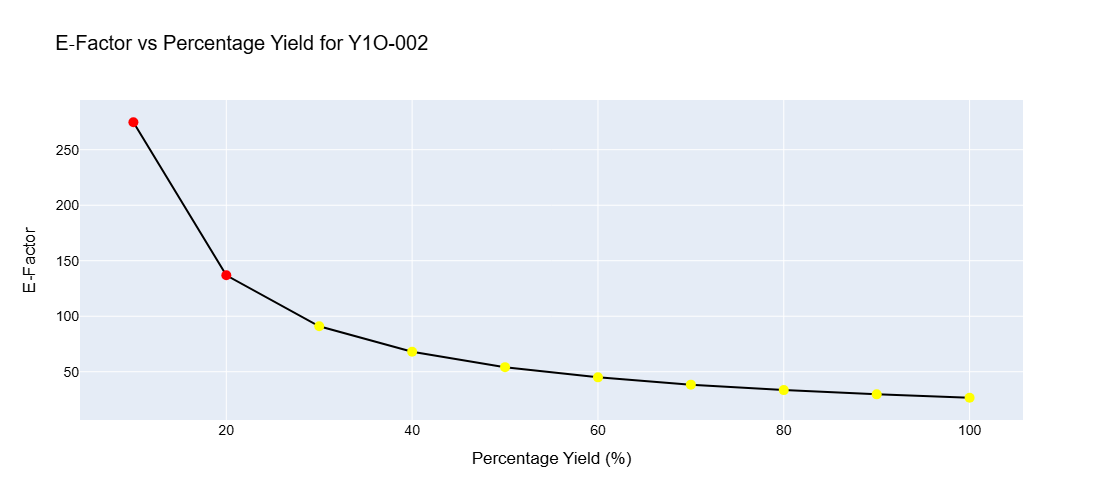

In [148]:
#plots the e-factor line graph for reaction 2
plot_single_reaction(df_e_factor_values, "Y1O-002")

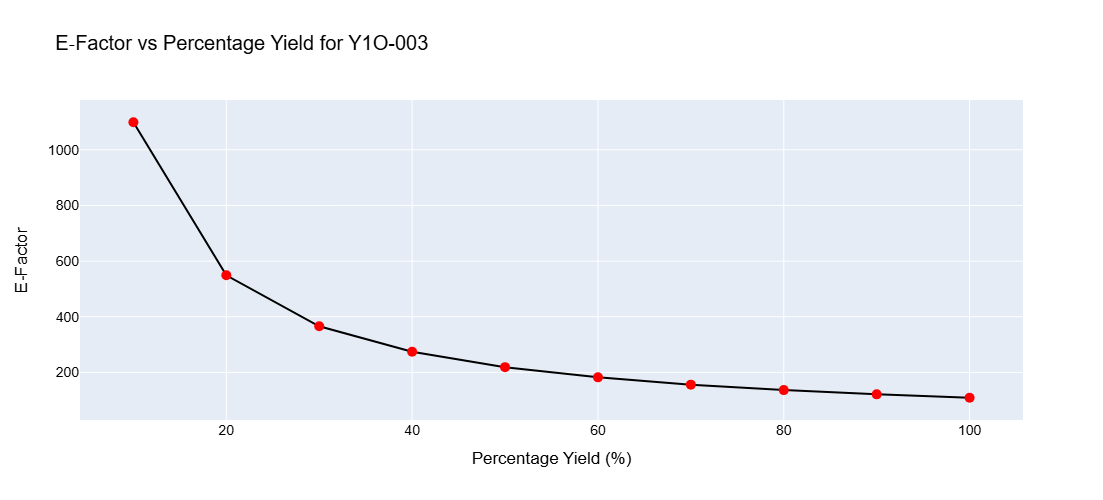

In [149]:
#plots the e-factor line graph for reaction 3
plot_single_reaction(df_e_factor_values, "Y1O-003")

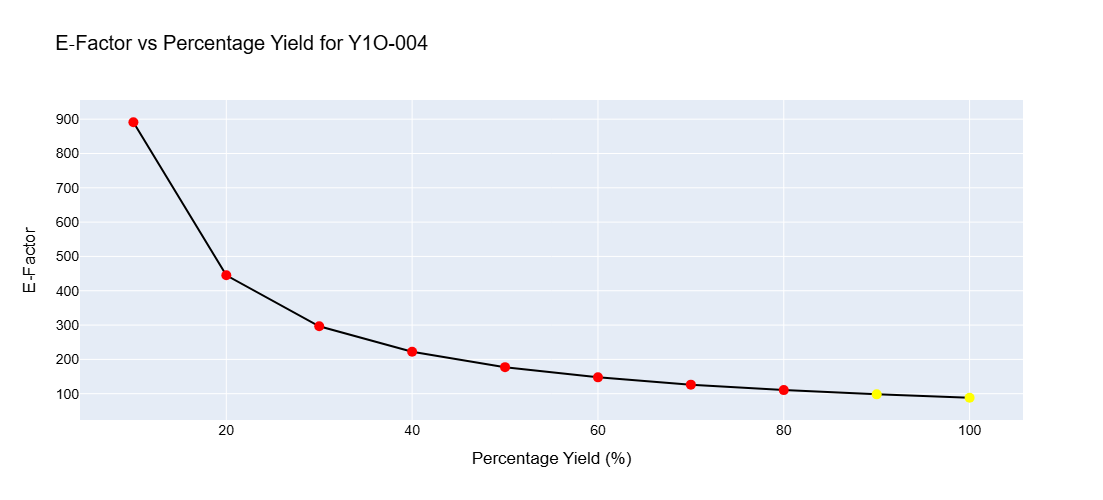

In [150]:
#plots the e-factor line graph for reaction 4
plot_single_reaction(df_e_factor_values, "Y1O-004")

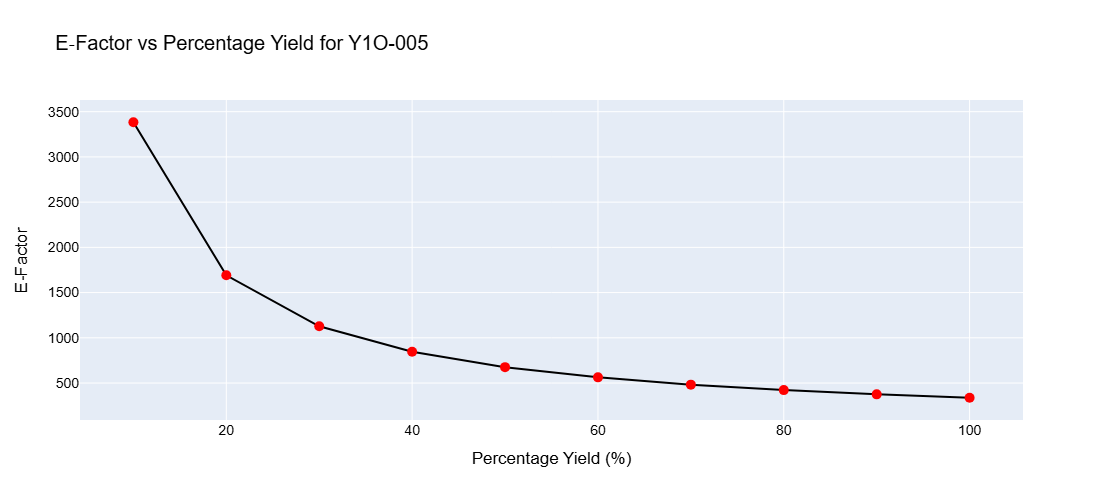

In [151]:
#plots the e-factor line graph for reaction 5
plot_single_reaction(df_e_factor_values, "Y1O-005")